# 04 — Baselines: single-vehicle time series (heavy_user)

This notebook didn't exist in the original project — its absence was one of the coach's fair
critiques. His own curriculum (notebook 5 of his practice set) is explicit: **always compute naive
baselines before any real model, and never delete them from the final comparison table.** If a
real model can't clearly beat these, its added complexity isn't earning its place.

Two baselines, both fixed rules — no fitting, no class weighting, nothing to tune:

1. **Majority-class baseline** — always predict the more common class. Answers "how well would we
   do by ignoring the data completely?"
2. **Naive persistence baseline** — predict `Fault_Within_6h = True` if a fault or warning occurred
   in the last 6 hours, else `False`. Answers "how well would we do with the simplest possible
   real-world heuristic, no model at all?"

Both are evaluated on the exact same chronological test split every later model will be evaluated
on, so the comparison is fair and directly comparable — same rows, same metrics, every time.


In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load — same data, same split logic as notebooks 02/03

In [2]:
df = pd.read_csv("../data/processed/heavy_user_features.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df["Fault_Within_6h"] = df["Fault_Within_6h"].astype(bool)

TEST_FRAC = 0.2
cutoff = int(len(df) * (1 - TEST_FRAC))
train_df = df.iloc[:cutoff].copy()
test_df = df.iloc[cutoff:].copy()

y_train = train_df["Fault_Within_6h"]
y_test = test_df["Fault_Within_6h"]

print(f"Train: {len(train_df):,} rows, {y_train.mean()*100:.2f}% positive")
print(f"Test:  {len(test_df):,} rows, {y_test.mean()*100:.2f}% positive")


Train: 35,016 rows, 14.45% positive
Test:  8,755 rows, 15.56% positive


## 2. Baseline 1 — majority class

The training set is ~85% "no fault in the next 6h," so the majority-class rule always predicts
`False`.


In [3]:
majority_class = y_train.mode()[0]
print(f"Majority class in train: {majority_class}")

pred_majority = pd.Series(majority_class, index=y_test.index)

print(classification_report(y_test, pred_majority, labels=[False, True], digits=6, zero_division=0))


Majority class in train: False
              precision    recall  f1-score   support

       False   0.844432  1.000000  0.915655      7393
        True   0.000000  0.000000  0.000000      1362

    accuracy                       0.844432      8755
   macro avg   0.422216  0.500000  0.457828      8755
weighted avg   0.713065  0.844432  0.773208      8755



**Reading this:** this will score very high accuracy (because the classes are imbalanced) but
zero recall on the positive class — it never predicts a fault, so it never catches one. This is
exactly why accuracy is the wrong headline metric, and it's the cleanest possible illustration of
that fact, worth keeping in the write-up for exactly this reason.


## 3. Baseline 2 — naive persistence

The real-world heuristic a fleet manager might already use without any model: "if something was
wrong recently, assume it's still likely to be wrong soon." Predict `Fault_Within_6h = True` if
`is_fault` was `True` at any point in the last 6 hours (looking backward — not the same window as
the forward-looking target, which looks ahead).


In [4]:
LOOKBACK = 6
df["recent_fault_6h"] = (
    df["is_fault"].rolling(window=LOOKBACK, min_periods=1).max().astype(bool)
)

# Re-slice train/test now that the new column exists.
train_df = df.iloc[:cutoff].copy()
test_df = df.iloc[cutoff:].copy()

pred_persistence = test_df["recent_fault_6h"]

print(classification_report(y_test, pred_persistence, labels=[False, True], digits=6, zero_division=0))


              precision    recall  f1-score   support

       False   0.846476  0.846476  0.846476      7393
        True   0.166667  0.166667  0.166667      1362

    accuracy                       0.740720      8755
   macro avg   0.506572  0.506572  0.506572      8755
weighted avg   0.740720  0.740720  0.740720      8755



**Reading this:** if this beats the majority-class baseline by a wide margin, it tells us the
target has real short-term autocorrelation — faults cluster, they don't appear out of nowhere with
no local warning sign. That's directly useful context for the rolling/lag features built in
notebook 02: if a dead-simple lookback rule already captures a lot of signal, the fancier engineered
features need to clearly add *more* than this, not just replicate what a lookback already gives us
for free.


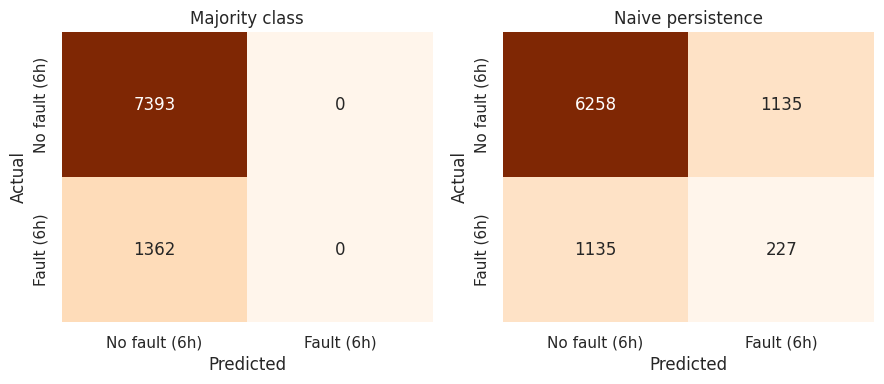

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pred, name in zip(axes, [pred_majority, pred_persistence], ["Majority class", "Naive persistence"]):
    cm = confusion_matrix(y_test, pred, labels=[False, True])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax, cbar=False,
                xticklabels=["No fault (6h)", "Fault (6h)"], yticklabels=["No fault (6h)", "Fault (6h)"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


## 4. Baseline scoreboard — the table every later model has to beat

**Metric update (per coach feedback, checked directly):** a DummyClassifier that never predicts a
fault still scores macro F1 ~0.48 — deceptively OK-looking for a completely useless model, because
macro F1 averages in the negative class's near-perfect score. From here on, **`True` (fault) is the
positive class, and precision/recall/F1 on that class are the headline numbers.** Macro F1 is kept
only as a secondary reference column, not the metric used to judge a model.


In [6]:
baseline_results = {
    "Majority class": {
        "recall_fault": recall_score(y_test, pred_majority, pos_label=True, zero_division=0),
        "precision_fault": precision_score(y_test, pred_majority, pos_label=True, zero_division=0),
        "F1_fault": f1_score(y_test, pred_majority, pos_label=True, zero_division=0),
        "macro_F1_secondary": f1_score(y_test, pred_majority, average="macro", zero_division=0),
    },
    "Naive persistence (6h lookback)": {
        "recall_fault": recall_score(y_test, pred_persistence, pos_label=True, zero_division=0),
        "precision_fault": precision_score(y_test, pred_persistence, pos_label=True, zero_division=0),
        "F1_fault": f1_score(y_test, pred_persistence, pos_label=True, zero_division=0),
        "macro_F1_secondary": f1_score(y_test, pred_persistence, average="macro", zero_division=0),
    },
}

scoreboard = pd.DataFrame(baseline_results).T.round(6)
scoreboard


,recall_fault,precision_fault,F1_fault,macro_F1_secondary
Majority class,0.000000,0.000000,0.000000,0.457828
Naive persistence (6h lookback),0.166667,0.166667,0.166667,0.506572


In [7]:
with open("../models/baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

print("Saved baseline_results.json — every later notebook appends its own results to this same")
print("comparison, rather than reporting numbers in isolation.")


Saved baseline_results.json — every later notebook appends its own results to this same
comparison, rather than reporting numbers in isolation.


## 5. What this notebook establishes, going into notebook 05

1. A real, checked reference point exists now — this was fully missing before.
2. Naive persistence tells us how much signal is available from the crudest possible heuristic;
   any real model's recall/precision needs to be read next to this number, not in isolation.
3. `baseline_results.json` is the seed of a running scoreboard — logistic regression (05) and tree
   models (06) both load and append to it, so the final comparison table is built incrementally and
   honestly, not reconstructed from memory at the end.
